# Decision trees
A supervised learning method used for classification and regression tasks. The goal is to create a model that predicts the value of a target variable by learning simple decision rules inferred from the data features.

## Components
- **Root node:** The top node in the tree that represents the best feature to split the data.
- **Internal nodes:** Represents the features used for splitting the data based on specific decision rules.
- **Leaf nodes:** Terminal nodes that represent the predicted outcome.
- **Branches:** Connections between nodes representing the possible values of the features.

## How it works?
It recursively partitions the data into subsets based on feature values, making decisions at each node to maximize/minimize a specific criterion (aka split criterion). The algorithm is described in the following way:

1. Split your dataset considering different features and their threshold value (that's the value used for comparing in the condition, for instance, if condition is `sqrt_feets > 9`, `9` is the threshold and `sqrt_feets` is the feature).
2. Calculate a metric like Gini impurity or information gain to each split.
3. Select the best split based on the metric.
4. Create 2 (or more for categorical variables) sub-splits based on the selected condition and pass them to the corresponding child node.
5. Repeat this procedure in the children until reaching a stop criterion (max depth is reached, no splits left, etc).

## Measures for choosing the best attribute
Choosing a good attribute depends on the selected measure, each task has its own measure, for instance, in regression tasks "mean squared error" is the most used. Let's talk about the most important measures, defined for classification tasks.
### Regression
Measures like mean squared error (MSE), mean absolute error (MAE) or mean Poisson deviance are calculated for each data split. As you can guess, we need to define a $\bar{y}$ for using those measures, often this is achieved choosing the mean or the median of the data split. For instance, with MAE the definition is:

<center>
    $MAE(S) = \frac{1}{n_{S}}\sum_{y \in S}|y-median_{S}(y)|$
</center>

where:
- $S$ is the data sample.
- $y$ is the target variable of a data instance.
- $n_{S}$ is the size of $S$.
- $median_{S}(y)$ is the median of $y$ variable in data split $S$

### Classification
#### Entropy
A concept from information theory, which measures the impurity within a dataset. In a common vocabulary, is the measure of disorder or uncertainty. When building a decision tree, the goal is to reduce entropy with each splits to create subsets that are as pure as possible ("pure" means that there is just a single class in a node/data split).

<center>
    $Entropy(S)= - \sum_{i=1}^{n}p_{i}log_{2}(p_{i})$
</center>

where:
- $S$ is the dataset to be evaluated.
- $p_{i}$ is the probability of class $i$ in the dataset.
- $n$ is the number of unique classes in the dataset.

#### Gini impurity
Checks how often a randomly selected sample would be mislabeled if assigned by class probability.

<center>
    $Gini(S)= 1-\sum_{i=1}^{n}p_{i}^{2}$
</center>

where $p_{i}$ is the probability of class $i$ in the dataset.

## How model outputs are calculated?
### Classification
Model outcome is the most frequent label in leaf node instances.

Accuracy: 75.000000 %
Weighted F1-Score: 75.261982 %


[Text(0.5, 0.875, 'ram <= 2241.5\ngini = 0.75\nsamples = 1600\nvalue = [413, 400, 384, 403]\nclass = Low'),
 Text(0.25, 0.625, 'ram <= 1123.5\ngini = 0.58\nsamples = 844\nvalue = [413, 349, 82, 0]\nclass = Low'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'screen_height_pixels <= 1506.5\ngini = 0.201\nsamples = 379\nvalue = [336, 43, 0, 0]\nclass = Low'),
 Text(0.0625, 0.125, 'gini = 0.147\nsamples = 362\nvalue = [333, 29, 0, 0]\nclass = Low'),
 Text(0.1875, 0.125, 'gini = 0.291\nsamples = 17\nvalue = [3, 14, 0, 0]\nclass = Regular'),
 Text(0.375, 0.375, 'battery_power <= 1002.5\ngini = 0.508\nsamples = 465\nvalue = [77, 306, 82, 0]\nclass = Regular'),
 Text(0.3125, 0.125, 'gini = 0.51\nsamples = 161\nvalue = [65.0, 92.0, 4.0, 0.0]\nclass = Regular'),
 Text(0.4375, 0.125, 'gini = 0.437\nsamples = 304\nvalue = [12, 214, 78, 0]\nclass = Regular'),
 Text(0.75, 0.625, 'ram <= 3116.0\ngini = 0.552\nsamples = 756\nvalue = [0.0, 51.0, 302.0, 403.0]\nclass = Expensive'),
 Text(0.625, 0.

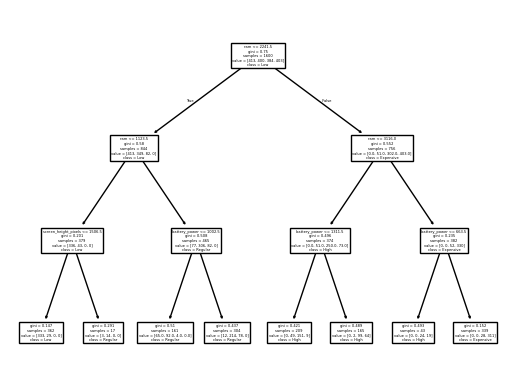

In [1]:
from pandas import read_csv
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, f1_score

data = read_csv("/kaggle/input/datasets/iabhishekofficial/mobile-price-classification/train.csv")
COL_MAPPER = {"fc": "front_camera_pixels", "four_g": "has_4g", "int_memory": "storage_size", 
              "mobile_wt": "weight", "m_dep": "depth_cm", "n_cores": "cpu_cores", "pc": "rear_camera_pixels",
              "px_width": "screen_width_pixels", "px_height": "screen_height_pixels", "sc_w": "screen_width_cm",
              "sc_h": "screen_height_cm", "three_g": "has_3g", "touch_screen": "has_touch_screen", "wifi": "has_wifi",
              "blue": "has_bluetooth", "clock_speed": "cpu_clock_speed"}

renamed_data = data.rename(columns=COL_MAPPER)

NUMS = ["battery_power","cpu_clock_speed", "depth_cm", "front_camera_pixels", "storage_size", "weight", "cpu_cores",
       "rear_camera_pixels", "screen_height_pixels","screen_width_pixels","ram","screen_height_cm","screen_width_cm","talk_time"]
BINS = ["has_4g", "has_3g", "has_bluetooth", "dual_sim", "has_wifi", "has_touch_screen"]
FEATURES = NUMS + BINS
TAG = "price_range"

X_train, X_test, y_train, y_test = train_test_split(renamed_data[FEATURES], renamed_data[TAG], train_size=0.8, random_state=123)

# Model definition
CLASSIFICATION_MODEL = DecisionTreeClassifier(random_state=123, max_depth=3, criterion="gini")
CLASSIFICATION_MODEL.fit(X_train, y_train)
y_pred = CLASSIFICATION_MODEL.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1Score = f1_score(y_test, y_pred, average="weighted")
print(f"Accuracy: {(accuracy*100):2f} %")
print(f"Weighted F1-Score: {(f1Score*100):2f} %")

plot_tree(CLASSIFICATION_MODEL, feature_names=X_train.columns, class_names=["Low", "Regular", "High", "Expensive"])

### Regression
In constrast to classification tasks, model's output is calculated as the mean of target variable in leaf node instances.

Mean squared error: 1418507007.406934
Mean absolute error: 14380.258879


[Text(0.5, 0.875, 'user_ratings <= 4.57\nsquared_error = 1881006670.516\nsamples = 668\nvalue = 15574.482'),
 Text(0.25, 0.625, 'display_size_inches <= 5.45\nsquared_error = 306537517.648\nsamples = 628\nvalue = 10131.268'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'brand <= 18.0\nsquared_error = 10401749.787\nsamples = 400\nvalue = 1736.928'),
 Text(0.0625, 0.125, 'squared_error = 289000000.0\nsamples = 4\nvalue = 21999.0'),
 Text(0.1875, 0.125, 'squared_error = 3398751.627\nsamples = 396\nvalue = 1532.26'),
 Text(0.375, 0.375, 'ram <= 7.0\nsquared_error = 485569297.042\nsamples = 228\nvalue = 24858.18'),
 Text(0.3125, 0.125, 'squared_error = 191748563.392\nsamples = 160\nvalue = 18374.212'),
 Text(0.4375, 0.125, 'squared_error = 845232692.598\nsamples = 68\nvalue = 40114.574'),
 Text(0.75, 0.625, 'display_size_inches <= 6.15\nsquared_error = 18831853850.098\nsamples = 40\nvalue = 101032.95'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'user_ratings <= 4.65\nsquared_e

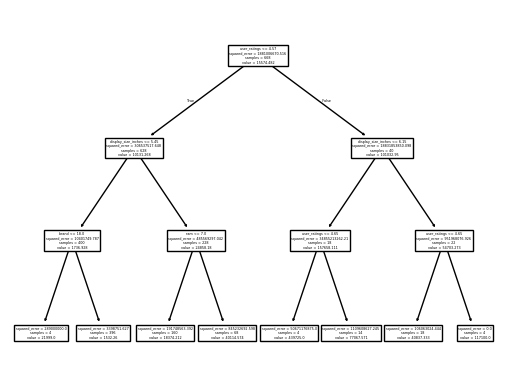

In [2]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error

data = read_csv("/kaggle/input/datasets/jsonali2003/mobile-price-prediction-dataset/Mobile Price Prediction Datatset.csv")

data = data.drop(columns=["Unnamed: 0"])
COL_MAPPER = {"Brand me": "brand", "Ratings": "user_ratings", "RAM": "ram", 
              "ROM": "storage_size", "Mobile_Size": "display_size_inches", "Primary_Cam": "main_camera_px", "Selfi_Cam": "selfie_camera_px",
              "Battery_Power": "battery", "Price": "price"}
renamed_data = data.rename(columns=COL_MAPPER)

NUMS = ["user_ratings","ram", "storage_size", "display_size_inches", "main_camera_px", "selfie_camera_px", "battery"]
CATS = ["brand"]
FEATURES = NUMS + CATS
TAG = "price"

x_train, x_test, y_train, y_test = train_test_split(renamed_data[FEATURES], renamed_data[TAG], train_size=0.8, random_state=123)

CAT_TRANSFORMER = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

TRANSFORMER = ColumnTransformer([
    ("num", KNNImputer(), NUMS),
    ("cat", CAT_TRANSFORMER, CATS)
])

X_train = TRANSFORMER.fit_transform(x_train)
X_test = TRANSFORMER.transform(x_test)

# Model definition
REGRESSION_MODEL = DecisionTreeRegressor(random_state=123, max_depth=3, criterion="squared_error")
REGRESSION_MODEL.fit(X_train, y_train)
y_pred = REGRESSION_MODEL.predict(X_test)

squared_error = mean_squared_error(y_test, y_pred)
absolute_error = mean_absolute_error(y_test, y_pred)
print(f"Mean squared error: {squared_error:2f}")
print(f"Mean absolute error: {absolute_error:2f}")

plot_tree(REGRESSION_MODEL, feature_names=x_train.columns)

## Most relevant hyperparameters
- **`criterion`:** Function used to measure the quality of a split (`gini`, `entropy`, `mae`, `mse`, etc).
- **`splitter`:** Strategy used to choose the split at each node.
- **`max_depth`:** Maximum depth of the tree, if not specified, nodes are expanded until leaves are pure or all leaves contains less than `min_samples_split` samples.
- **`min_samples_split`:** Minimum number of samples required to split an internal node.
- **`min_samples_leaf`:** Minimun number of samples required to be a leaf node.
- **`max_features`:** The number of features to consider when looking the best split.

## Advantages
- Doesn't requires extensive data preprocessing.
- Computational costs is low $O(log(n))$ because creates a balanced tree where data is splitted at every node.
- Supports multi-output tasks.
- It's an observable model, so you can plot the tree to understand easily how it works.
- Performs well with large datasets

## Disadvantages
- It's considered a weak learner, because can't learn too complex relationships among variables.
- It's an unstable technique, the minimal variation in data result in creating a completely different tree.
- Too sensitive to imbalanced datasets.
- Some regularization parameters must be tunned to avoid creating overfitted trees.
- Doesn't performs well for extrapolating values, works better for interpolation.
- In regression tasks, this technique imitates target function trend (as the output is the mean of leaf node instances) but doesn't perform well for accurate value forecasting.